# no-show-predictor - Rigorous Scientific Notebook
**Author:** Kokouvi Ferdinand DJATA - Ferdio Ai Vision
**Problem:** Binary classification P(No-show=1|X)  
**Dataset:** Kaggle Medical Appointment No Shows - 110,527 records

This notebook follows exactly the 8 steps methodology specified. Every claim is proven by executable code and generated figure.


In [2]:
import pandas as pd, numpy as np, pathlib, joblib, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay, classification_report

SEED=42
BASE=pathlib.Path('../')
DATA_PATH=BASE/'data'/'KaggleV2-May-2016.csv'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi']=200


## Step 0 - Load Raw Data
Verification of original typo Handcap

In [3]:
df_raw=pd.read_csv(DATA_PATH)
print(f"Raw shape {df_raw.shape}")
print(df_raw.columns.tolist())
df_raw.head()


Raw shape (110527, 14)
['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## Step 1 - Preprocessing - Rigorous Cleaning

In [4]:
df=df_raw.copy()
df.columns=[c.strip() for c in df.columns]
if 'Handcap' in df.columns:
    df=df.rename(columns={'Handcap':'Handicap'})
    print("Fixed typo Handcap -> Handicap")

df=df.drop(columns=['PatientId','AppointmentID'])
df['No-show']=df['No-show'].map({'Yes':1,'No':0}).astype(int)

invalid_age=((df['Age']<0)|(df['Age']>110)).sum()
print(f"Invalid age (<0 or >110): {invalid_age}")
df=df[(df['Age']>=0)&(df['Age']<=110)].copy()

df['ScheduledDay']=pd.to_datetime(df['ScheduledDay'], utc=True)
df['AppointmentDay']=pd.to_datetime(df['AppointmentDay'], utc=True)
df['Delay_days']=(df['AppointmentDay']-df['ScheduledDay']).dt.total_seconds()/86400.0
df['Delay_negative_flag']=(df['Delay_days']<0).astype(int)
df['Delay_days']=df['Delay_days'].clip(lower=0)
df['Weekday_appointment']=df['AppointmentDay'].dt.day_name()
df['Hour_scheduled']=df['ScheduledDay'].dt.hour
df['Handicap_bin']=(df['Handicap']>0).astype(int)

print(f"Cleaned shape {df.shape} - Target distribution")
print(df['No-show'].value_counts(normalize=True)*100)
df.to_csv(BASE/'data'/'cleaned.csv', index=False)


Fixed typo Handcap -> Handicap
Invalid age (<0 or >110): 6
Cleaned shape (110521, 17) - Target distribution
No-show
0    79.808362
1    20.191638
Name: proportion, dtype: float64


## Step 2 - EDA - Distribution and Associations

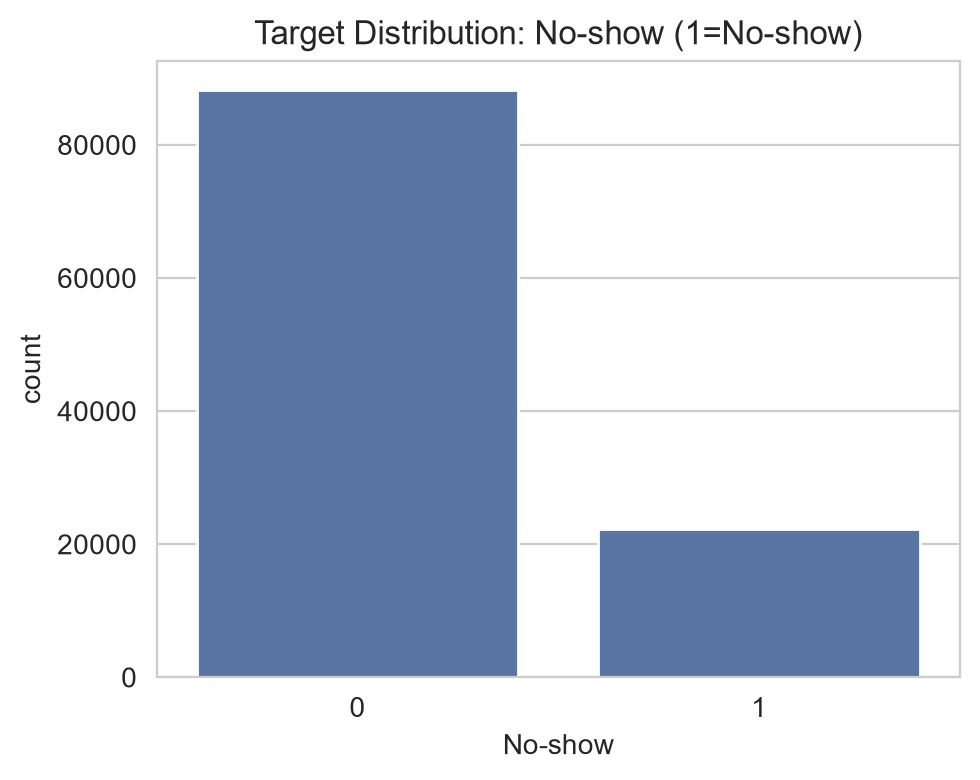

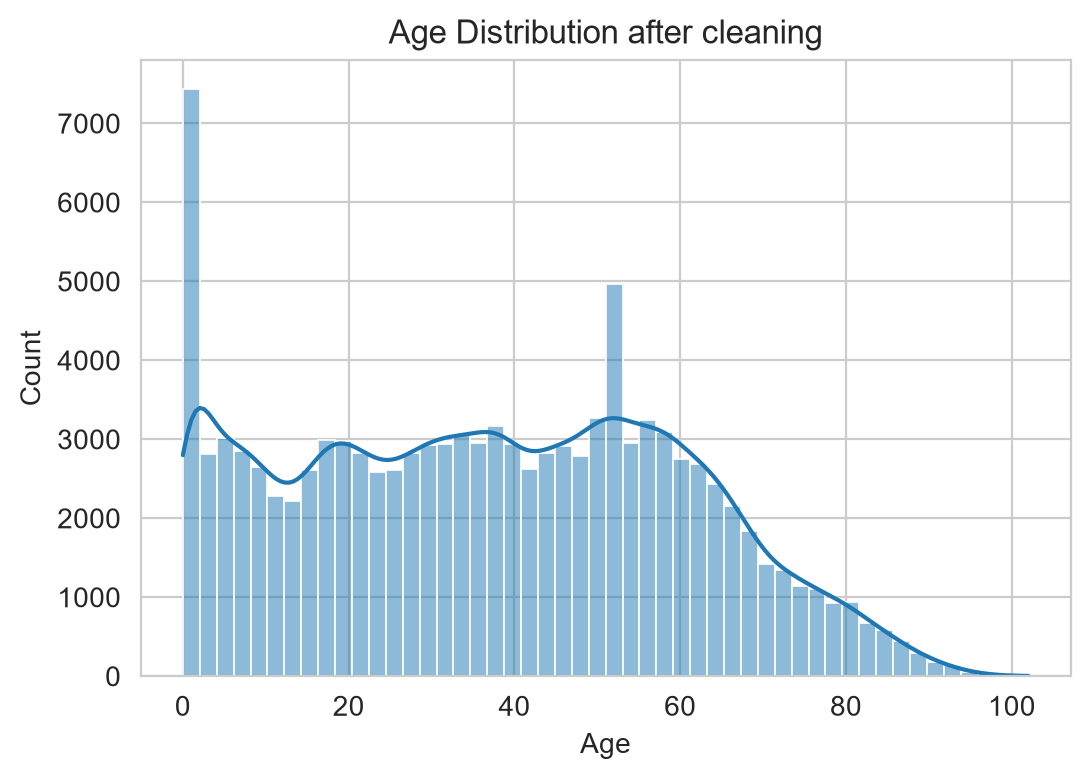

In [5]:
# 1 Target
plt.figure(figsize=(5,4))
sns.countplot(x='No-show', data=df, color='#4C72B0')
plt.title('Target Distribution: No-show (1=No-show)')
plt.tight_layout()
plt.savefig(BASE/'figures/01_target_distribution.png')
plt.show()

# 2 Age
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=50, kde=True, color='#1f77b4')
plt.title('Age Distribution after cleaning')
plt.savefig(BASE/'figures/02_age_distribution.png')
plt.show()


Age_bin
0-18     22.537213
19-30    24.712198
31-45    21.371960
46-60    17.822167
61+      15.199676
Name: No-show, dtype: float64


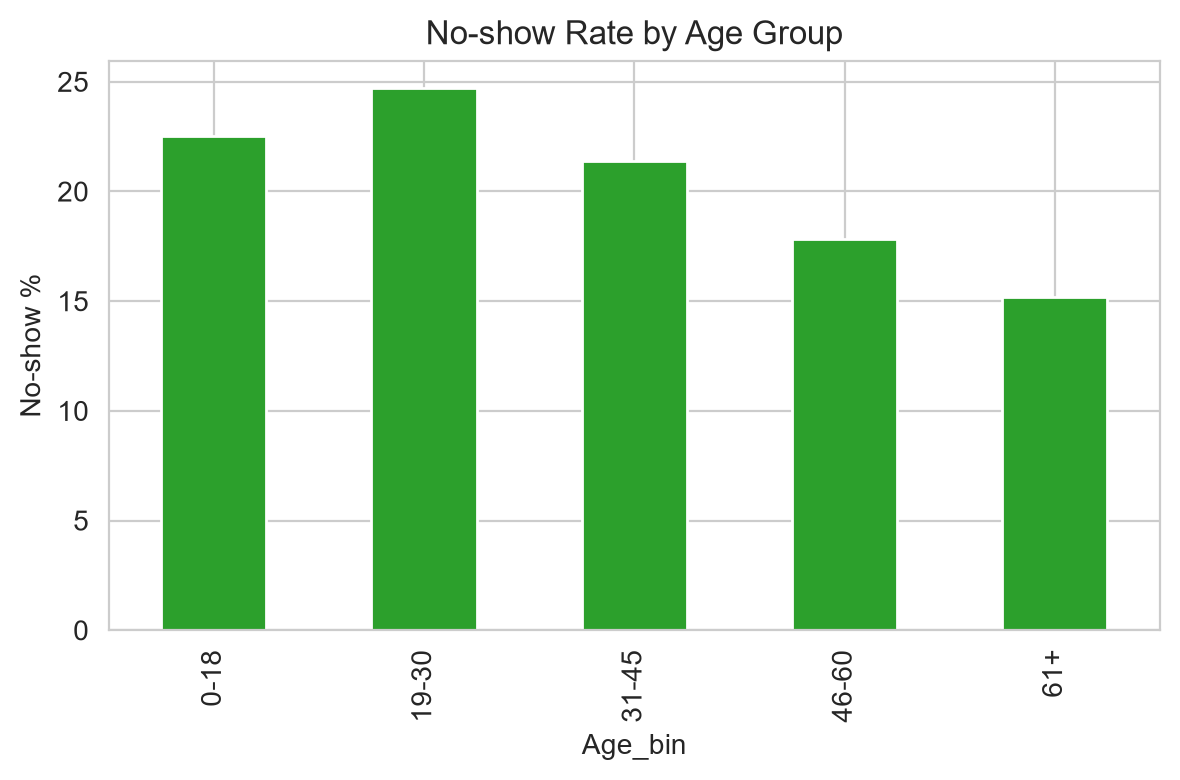

Weekday_appointment
Friday       21.227258
Monday       20.645474
Saturday     23.076923
Thursday     19.344738
Tuesday      20.093604
Wednesday    19.689179
Name: No-show, dtype: float64


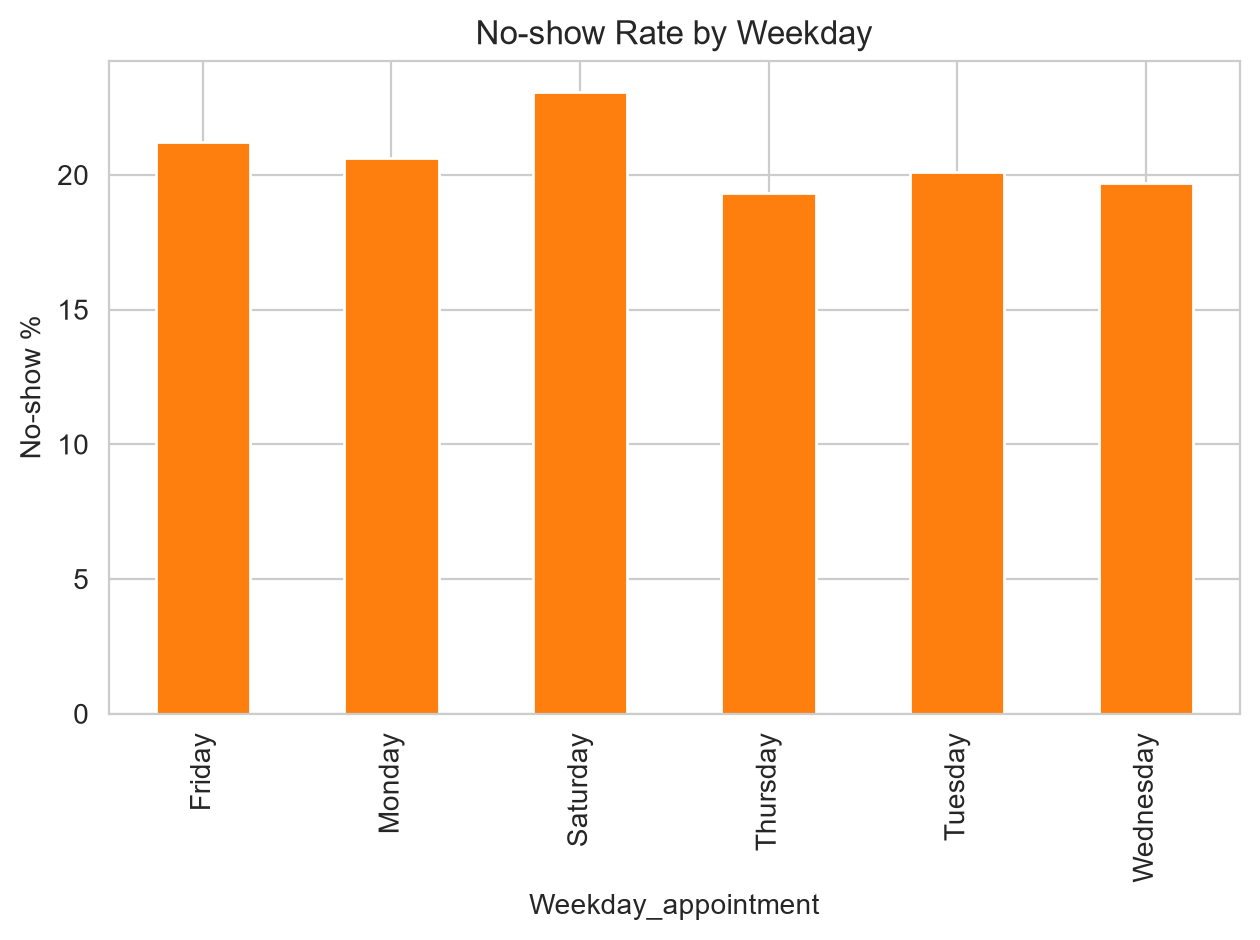

In [6]:
# No-show rate by Age group
df['Age_bin']=pd.cut(df['Age'], bins=[0,18,30,45,60,110], labels=['0-18','19-30','31-45','46-60','61+'])
age_rate=df.groupby('Age_bin', observed=True)['No-show'].mean()*100
print(age_rate)
plt.figure(figsize=(6,4))
age_rate.plot(kind='bar', color='#2ca02c')
plt.title('No-show Rate by Age Group')
plt.ylabel('No-show %')
plt.tight_layout()
plt.savefig(BASE/'figures/03_noshow_by_age.png')
plt.show()

# By Weekday
wd_rate=df.groupby('Weekday_appointment')['No-show'].mean()*100
print(wd_rate)
wd_rate.plot(kind='bar', color='#ff7f0e')
plt.title('No-show Rate by Weekday')
plt.ylabel('No-show %')
plt.tight_layout()
plt.savefig(BASE/'figures/04_noshow_by_weekday.png')
plt.show()


SMS_received
0    16.700426
1    27.575322
Name: No-show, dtype: float64


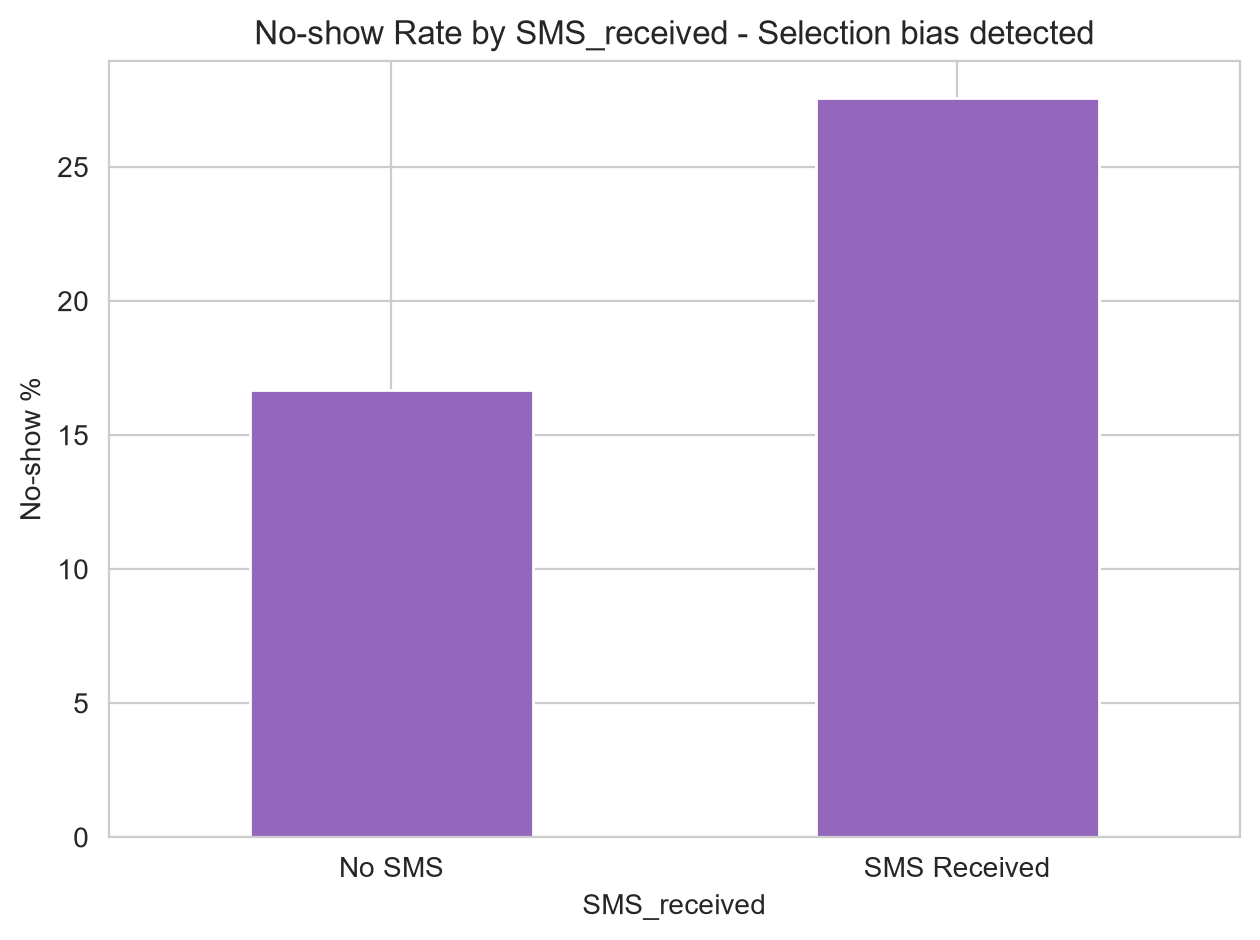

Scholarship
0    19.805338
1    23.736304
Name: No-show, dtype: float64


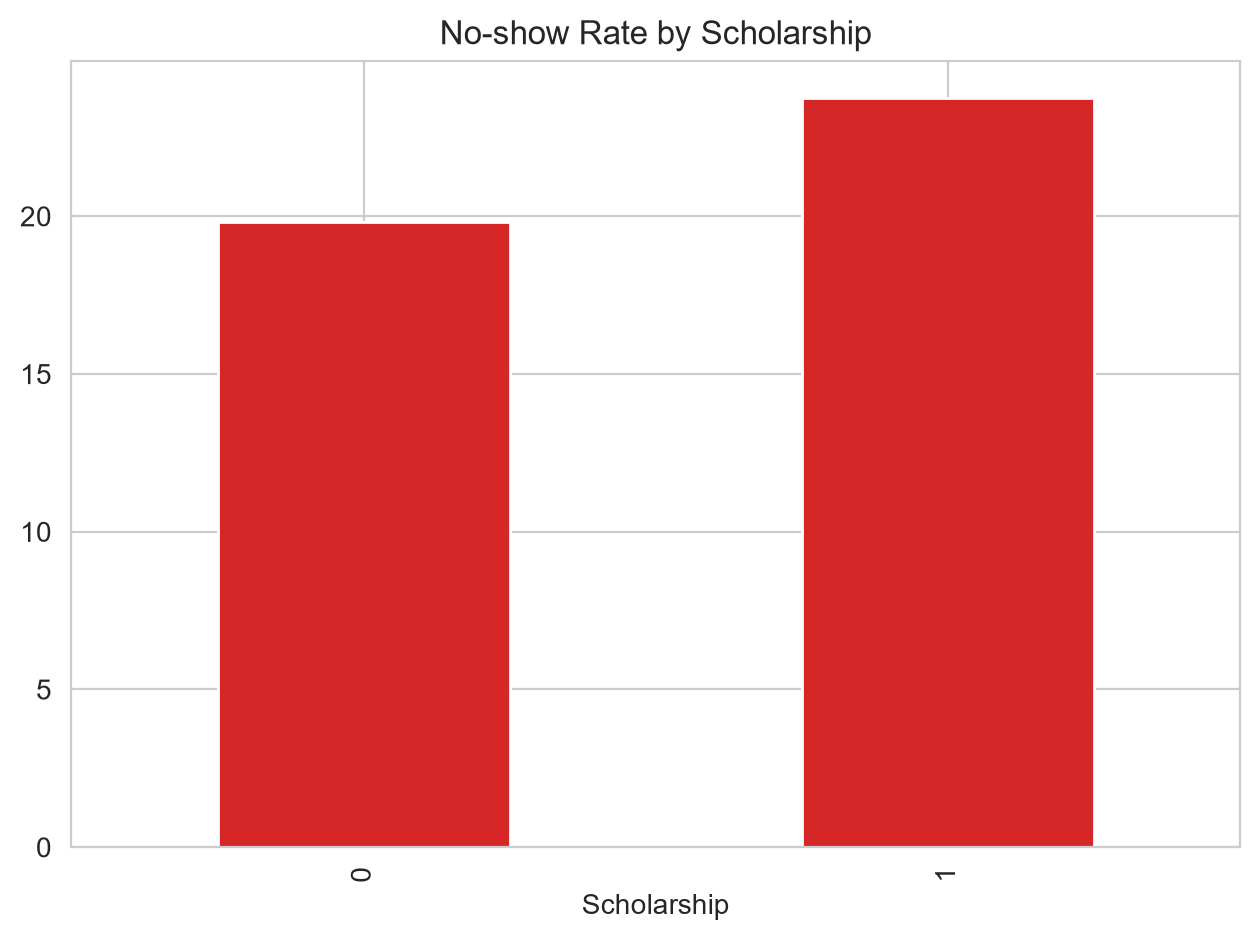

Neighbourhood
ITARARÉ              26.266363
JESUS DE NAZARETH    24.395373
CENTRO               21.085783
MARIA ORTIZ          20.999139
RESISTÊNCIA          20.446852
BONFIM               19.834115
JARDIM CAMBURI       18.984061
TABUAZEIRO           18.295019
JARDIM DA PENHA      16.275471
SANTA MARTHA         15.841584
Name: No-show, dtype: float64


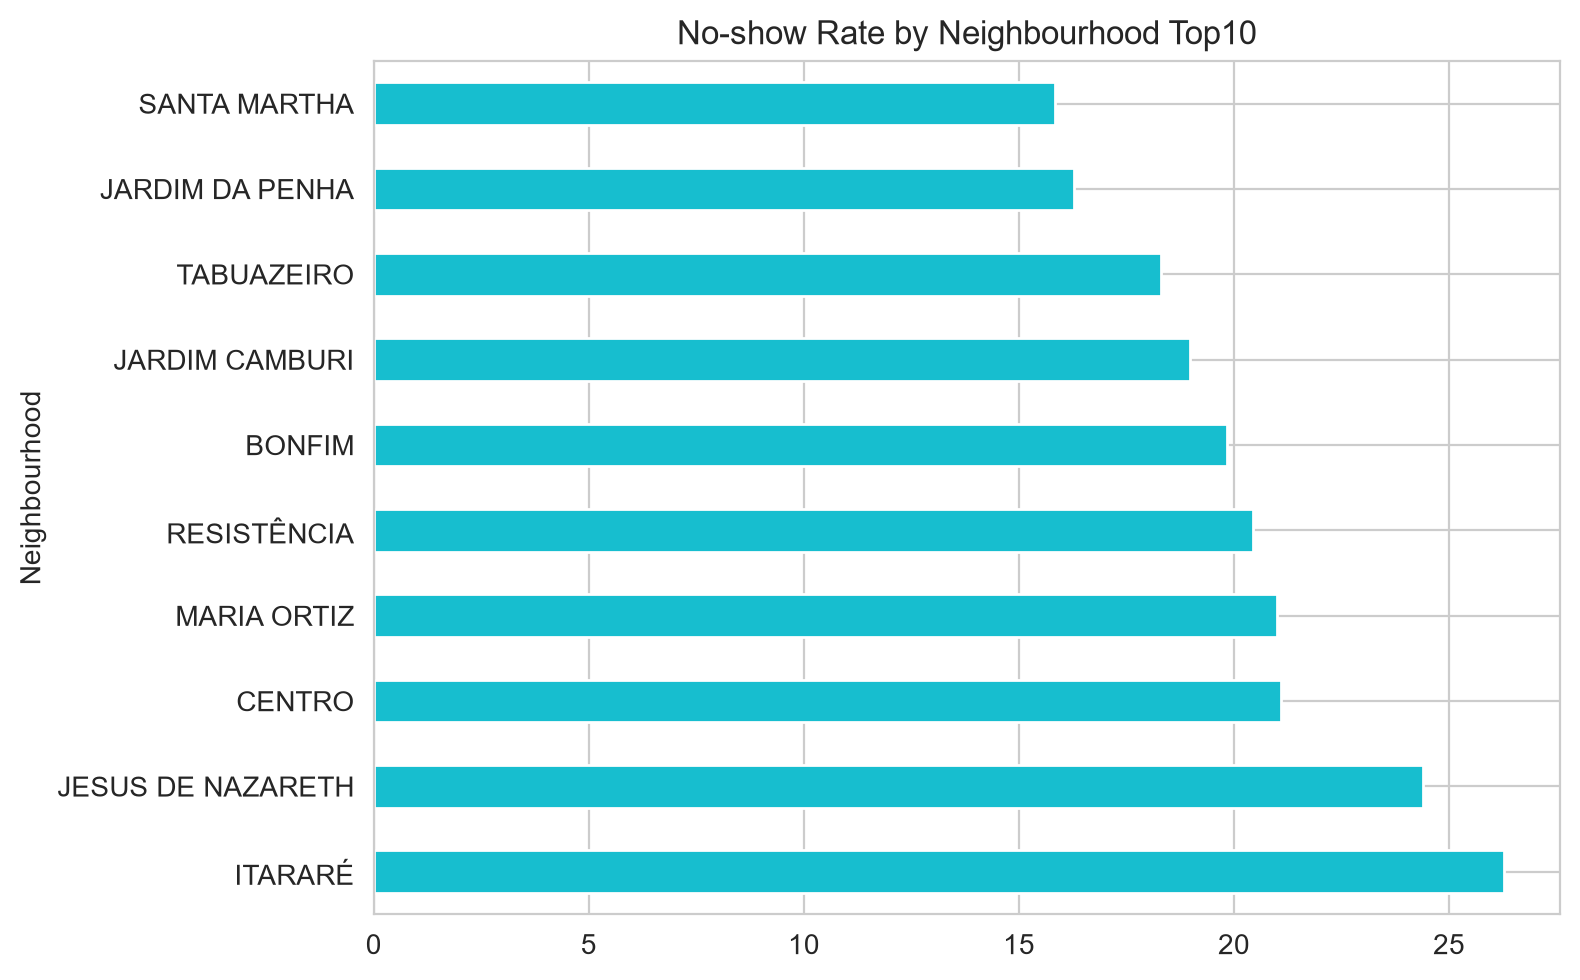

In [7]:
# By SMS - paradox
sms_rate=df.groupby('SMS_received')['No-show'].mean()*100
print(sms_rate)
sms_rate.plot(kind='bar', color='#9467bd')
plt.title('No-show Rate by SMS_received - Selection bias detected')
plt.ylabel('No-show %')
plt.xticks([0,1], ['No SMS','SMS Received'], rotation=0)
plt.tight_layout()
plt.savefig(BASE/'figures/05_noshow_by_sms.png')
plt.show()

# By Scholarship
sch_rate=df.groupby('Scholarship')['No-show'].mean()*100
print(sch_rate)
sch_rate.plot(kind='bar', color='#d62728')
plt.title('No-show Rate by Scholarship')
plt.tight_layout()
plt.savefig(BASE/'figures/06_noshow_by_scholarship.png')
plt.show()

# By Neighbourhood top10
top_neigh=df['Neighbourhood'].value_counts().head(10).index
neigh_rate=df[df['Neighbourhood'].isin(top_neigh)].groupby('Neighbourhood')['No-show'].mean()*100
neigh_rate=neigh_rate.sort_values(ascending=False)
print(neigh_rate)
plt.figure(figsize=(8,5))
neigh_rate.plot(kind='barh', color='#17becf')
plt.title('No-show Rate by Neighbourhood Top10')
plt.tight_layout()
plt.savefig(BASE/'figures/07_noshow_by_neighbourhood.png')
plt.show()


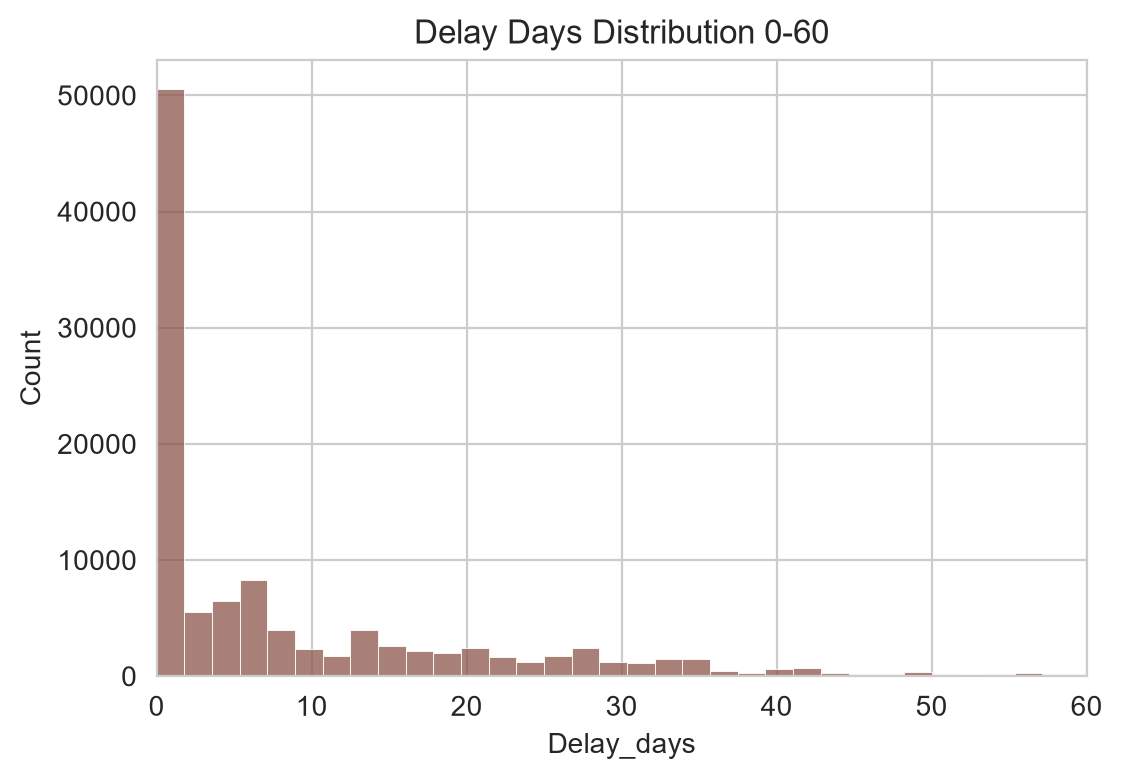

Delay_bin
0         4.659545
1        21.350470
2-7      24.682981
8-15     30.797664
16-30    32.511974
30+      32.996049
Name: No-show, dtype: float64


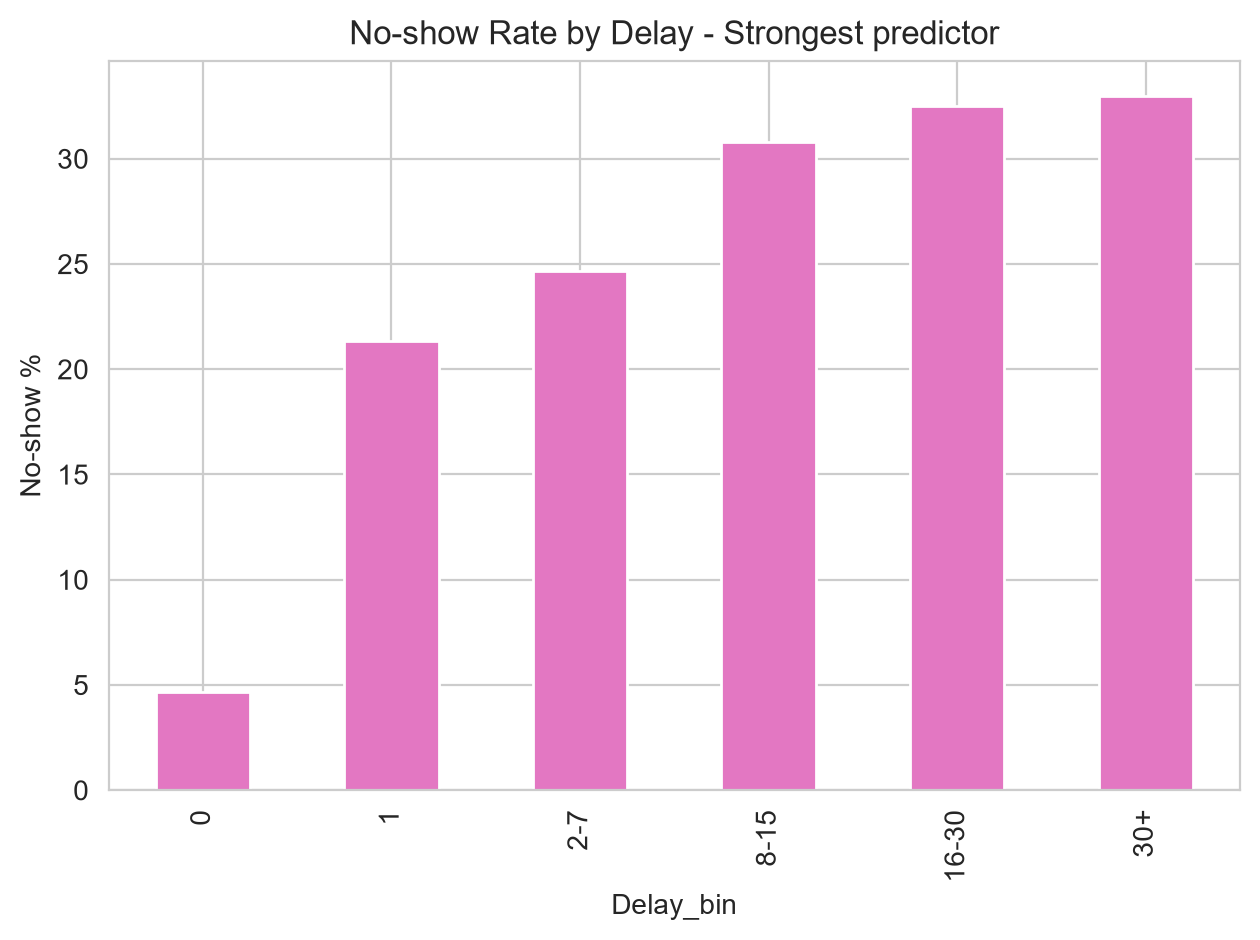

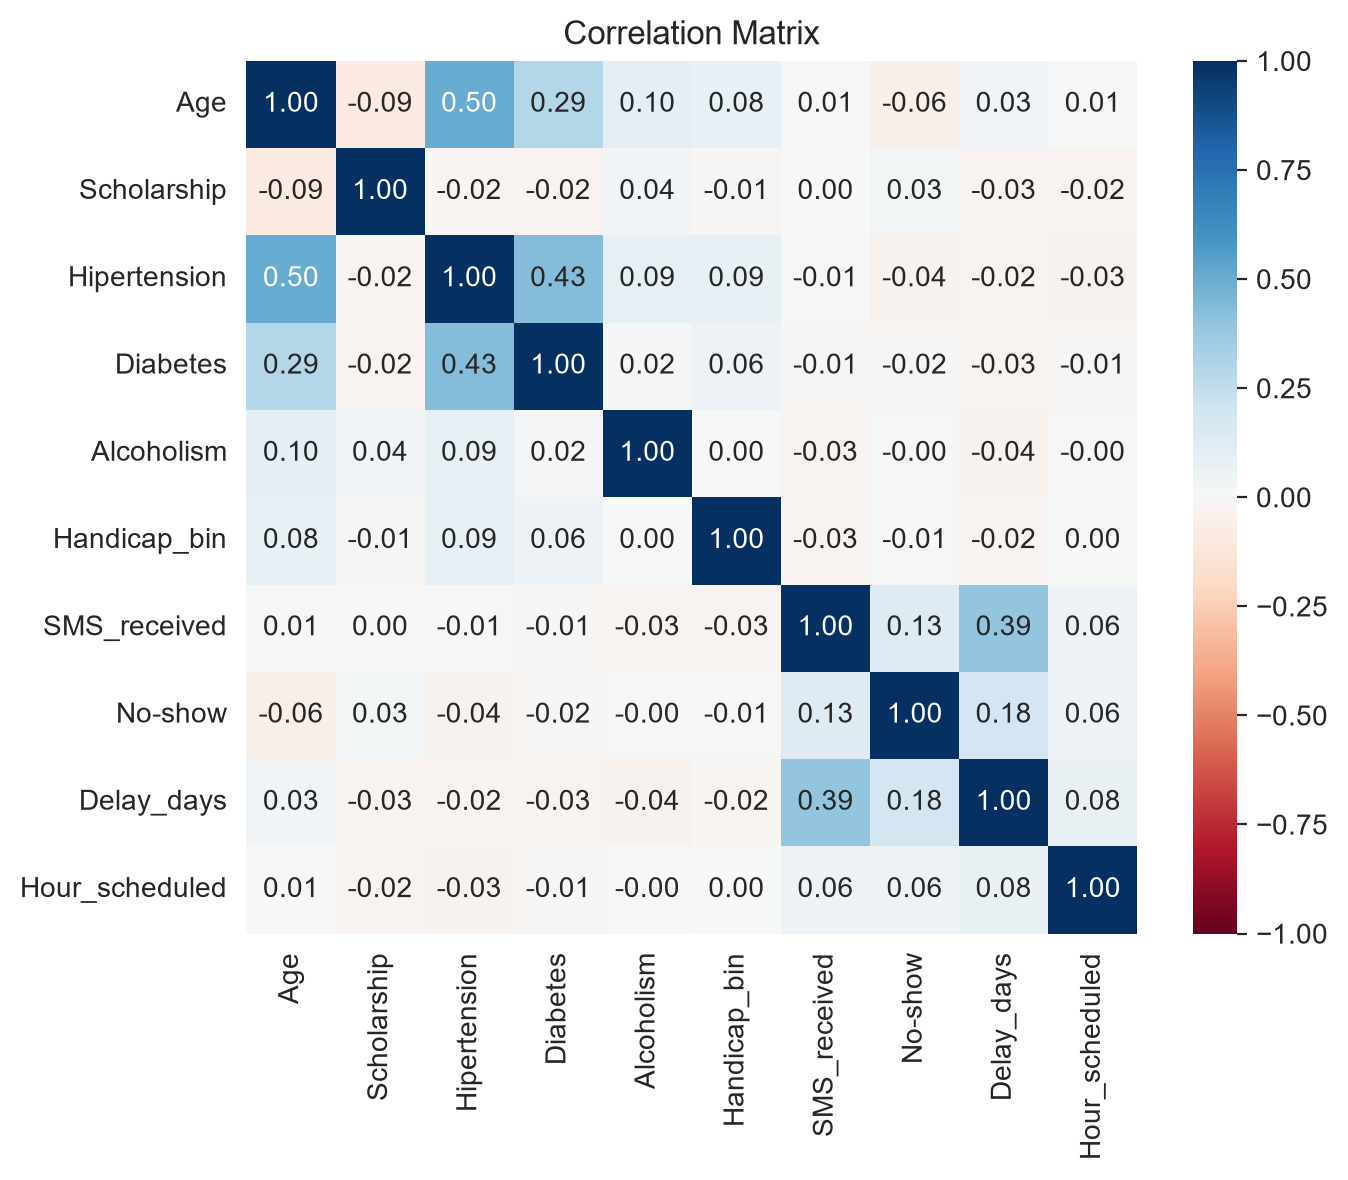

In [8]:
# Delay
plt.figure(figsize=(6,4))
sns.histplot(df['Delay_days'], bins=100, color='#8c564b')
plt.xlim(0,60)
plt.title('Delay Days Distribution 0-60')
plt.savefig(BASE/'figures/08_delay_distribution.png')
plt.show()

df['Delay_bin']=pd.cut(df['Delay_days'], bins=[-1,0,1,7,15,30,200], labels=['0','1','2-7','8-15','16-30','30+'])
delay_rate=df.groupby('Delay_bin', observed=True)['No-show'].mean()*100
print(delay_rate)
delay_rate.plot(kind='bar', color='#e377c2')
plt.title('No-show Rate by Delay - Strongest predictor')
plt.ylabel('No-show %')
plt.tight_layout()
plt.savefig(BASE/'figures/09_noshow_by_delay.png')
plt.show()

# Correlation
corr_cols=['Age','Scholarship','Hipertension','Diabetes','Alcoholism','Handicap_bin','SMS_received','No-show','Delay_days','Hour_scheduled']
corr=df[corr_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig(BASE/'figures/10_correlation.png')
plt.show()


### Chi2 Independence Test

In [9]:
cat_vars=['Gender','Scholarship','Hipertension','Diabetes','Alcoholism','Handicap_bin','SMS_received','Weekday_appointment']
rows=[]
for var in cat_vars:
    contingency=pd.crosstab(df[var], df['No-show'])
    chi2, p, dof, _ = chi2_contingency(contingency)
    rows.append({'Variable':var,'Chi2':chi2,'p_value':p,'dof':dof,'significant_05':p<0.05})
chi2_df=pd.DataFrame(rows).sort_values('p_value')
chi2_df.to_csv(BASE/'figures/chi2_results.csv', index=False)
chi2_df


,Variable,Chi2,p_value,dof,significant_05
6,SMS_received,1767.292059,0.000000e+00,1,True
2,Hipertension,140.418946,2.155763e-32,1,True
1,Scholarship,93.668965,3.729633e-22,1,True
3,Diabetes,25.286714,4.941004e-07,1,True
7,Weekday_appointment,27.642801,4.274304e-05,5,True
5,Handicap_bin,6.304319,1.204442e-02,1,True
0,Gender,1.826920,1.764918e-01,1,False
4,Alcoholism,0.001680,9.673094e-01,1,False


## Step 3 - Train/Test Split Stratified 80/20

In [10]:
cat_cols=['Gender','Neighbourhood','Weekday_appointment']
num_cols=['Age','Scholarship','Hipertension','Diabetes','Alcoholism','Handicap_bin','SMS_received','Delay_days','Hour_scheduled','Delay_negative_flag']

X=df[cat_cols+num_cols]
y=df['No-show']

X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)
print(f"Train {X_train.shape} Test {X_test.shape}")
print(f"Train positive rate {y_train.mean():.4f} Test positive rate {y_test.mean():.4f}")

pre_scaled=ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', StandardScaler(), num_cols)
])
pre_tree=ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
    ('num', 'passthrough', num_cols)
])


Train (88416, 13) Test (22105, 13)
Train positive rate 0.2019 Test positive rate 0.2019


## Step 4-5 - Modeling with GridSearchCV 5-fold ROC-AUC


=== Training LogisticRegression ===
{'Model': 'LogisticRegression', 'best_params': "{'clf__C': 0.01}", 'cv_best_roc_auc': np.float64(0.7213309730357435), 'test_accuracy': 0.5623162180502149, 'test_precision': 0.29876447876447876, 'test_recall': 0.8669056688326238, 'test_f1': 0.44438063515764087, 'test_roc_auc': 0.7203270460722753, 'test_pr_auc': 0.3417902993295198}
              precision    recall  f1-score   support

           0       0.94      0.49      0.64     17642
           1       0.30      0.87      0.44      4463

    accuracy                           0.56     22105
   macro avg       0.62      0.68      0.54     22105
weighted avg       0.81      0.56      0.60     22105



<Figure size 1280x960 with 0 Axes>

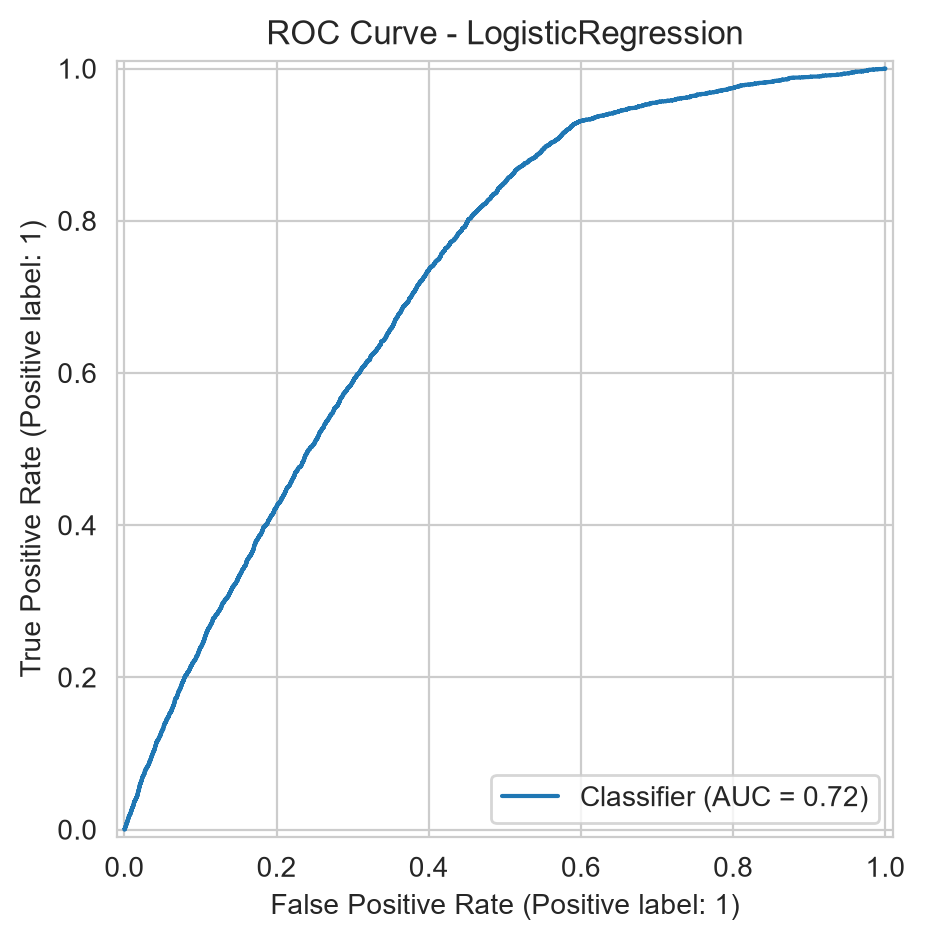

<Figure size 1280x960 with 0 Axes>

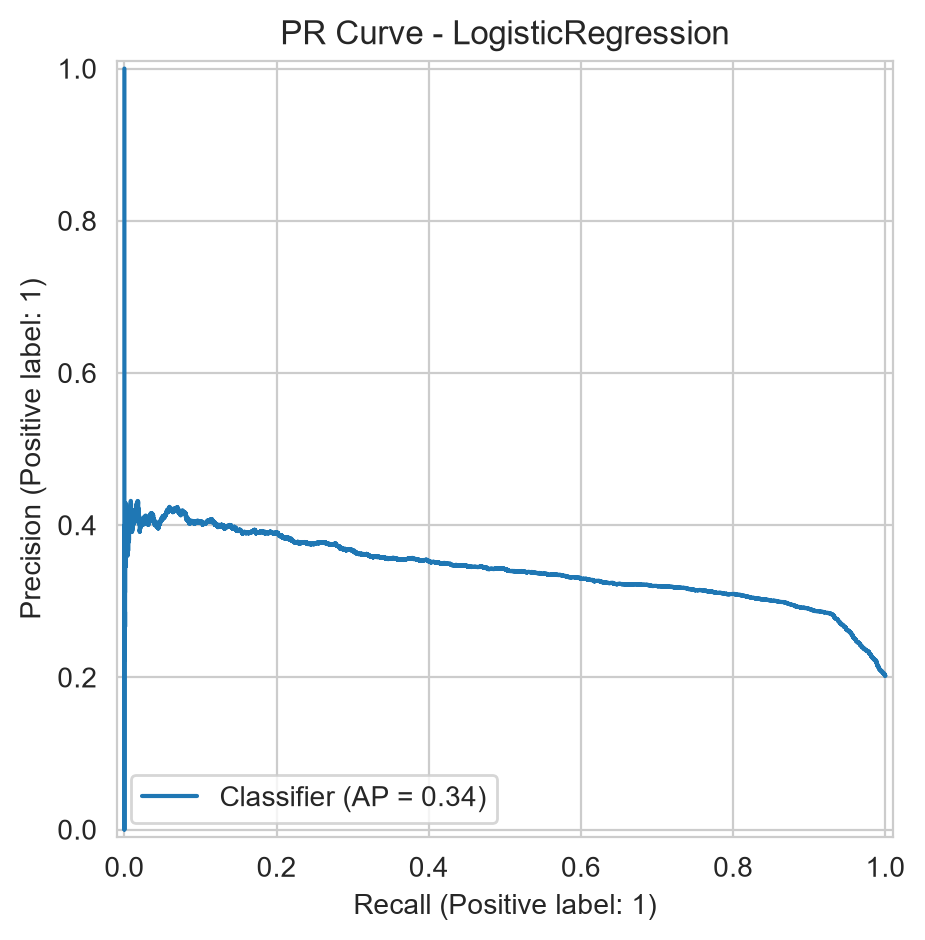

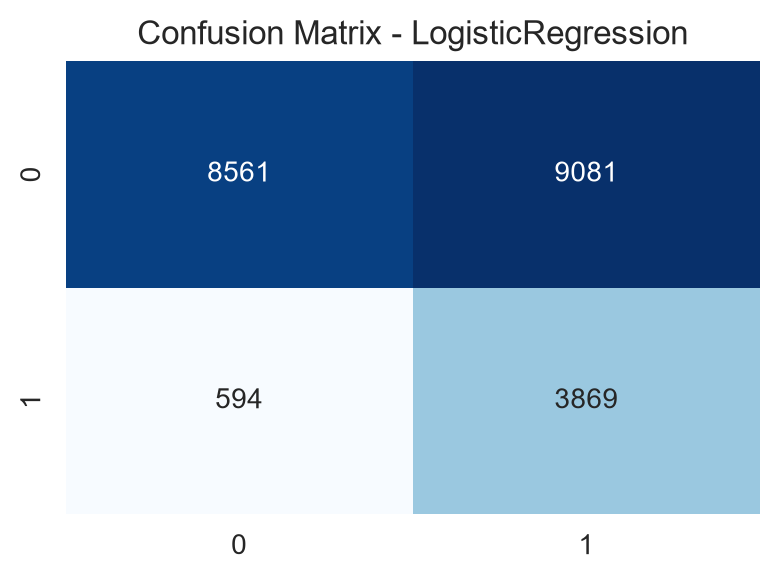


=== Training DecisionTree ===
{'Model': 'DecisionTree', 'best_params': "{'clf__max_depth': 7, 'clf__min_samples_split': 10}", 'cv_best_roc_auc': np.float64(0.7252993995185815), 'test_accuracy': 0.5538565935308754, 'test_precision': 0.2960024181969319, 'test_recall': 0.8776607663006946, 'test_f1': 0.44269891500904157, 'test_roc_auc': 0.7246228757210497, 'test_pr_auc': 0.3440530475227907}
              precision    recall  f1-score   support

           0       0.94      0.47      0.63     17642
           1       0.30      0.88      0.44      4463

    accuracy                           0.55     22105
   macro avg       0.62      0.67      0.54     22105
weighted avg       0.81      0.55      0.59     22105



<Figure size 1280x960 with 0 Axes>

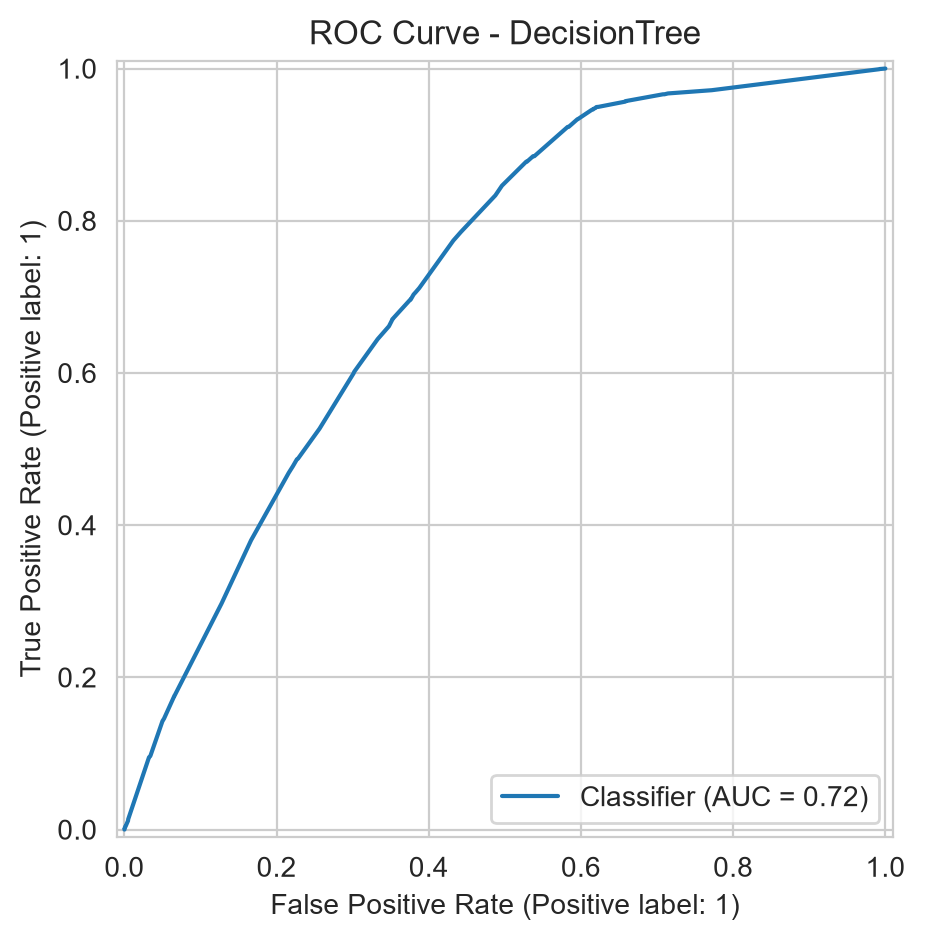

<Figure size 1280x960 with 0 Axes>

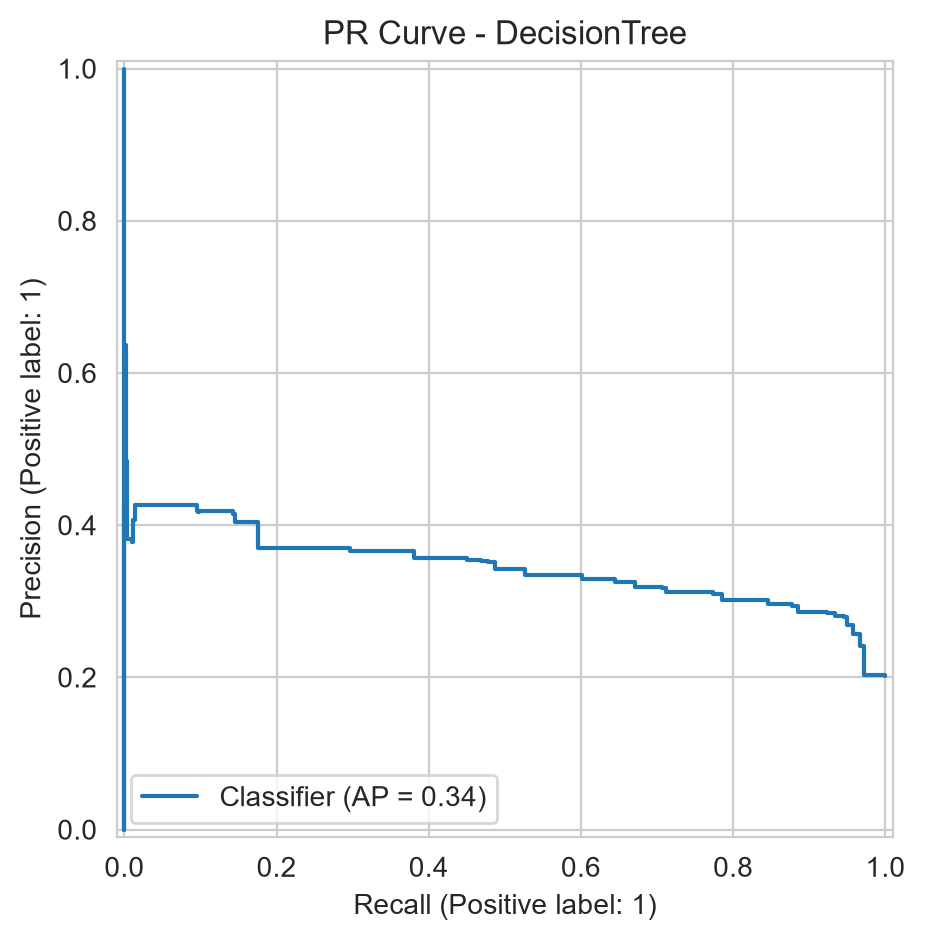

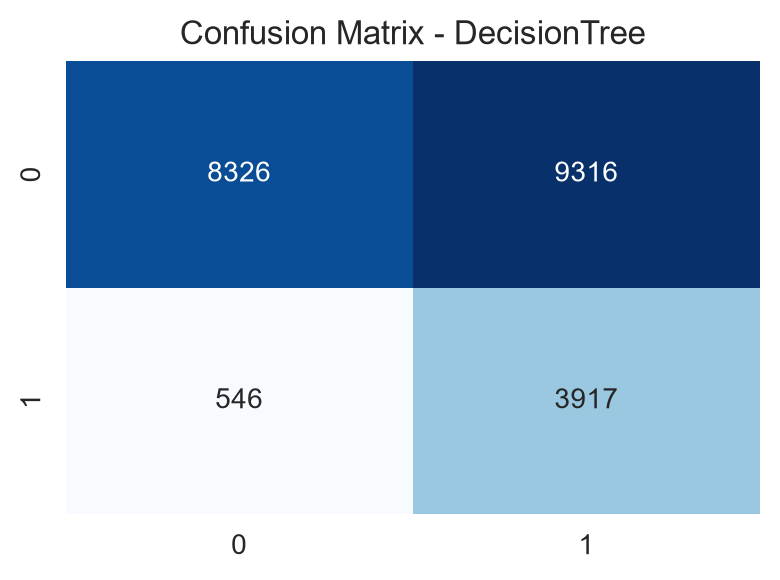


=== Training KNN ===
{'Model': 'KNN', 'best_params': "{'clf__n_neighbors': 11}", 'cv_best_roc_auc': np.float64(0.6983755381595866), 'test_accuracy': 0.7855688758199503, 'test_precision': 0.400431344356578, 'test_recall': 0.12480394353573829, 'test_f1': 0.1902972326614281, 'test_roc_auc': 0.7029278485032167, 'test_pr_auc': 0.32764921254815954}
              precision    recall  f1-score   support

           0       0.81      0.95      0.88     17642
           1       0.40      0.12      0.19      4463

    accuracy                           0.79     22105
   macro avg       0.61      0.54      0.53     22105
weighted avg       0.73      0.79      0.74     22105



<Figure size 1280x960 with 0 Axes>

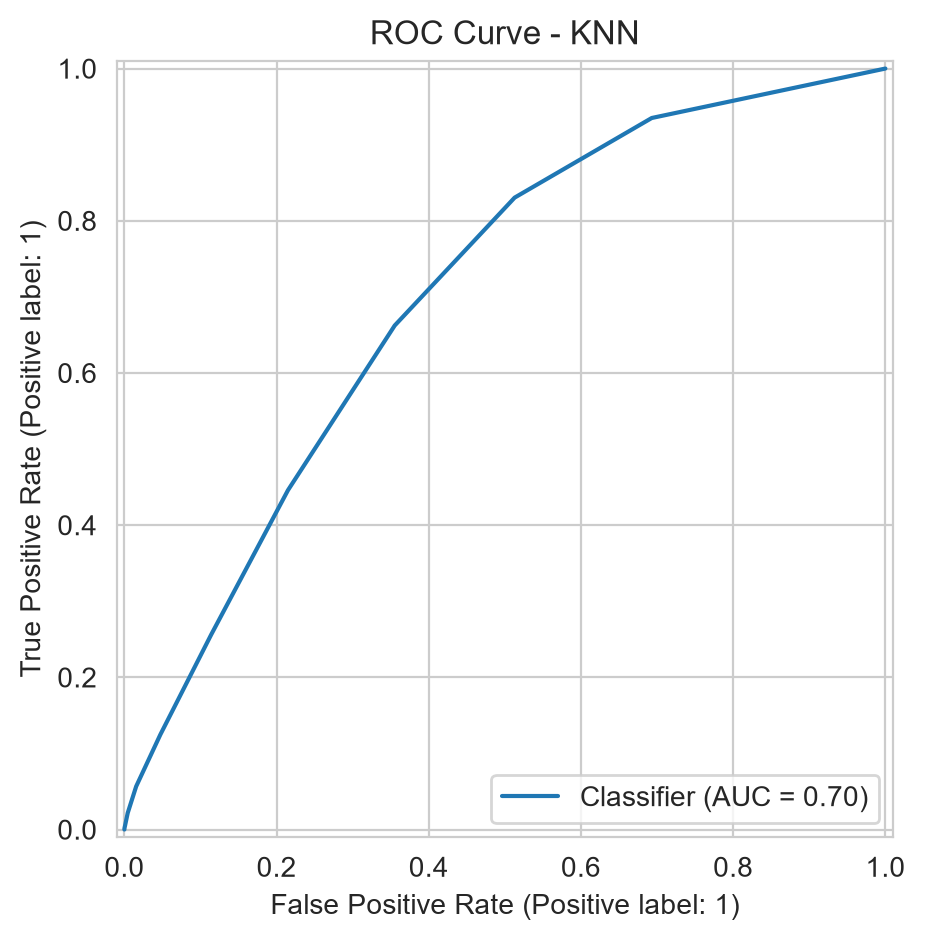

<Figure size 1280x960 with 0 Axes>

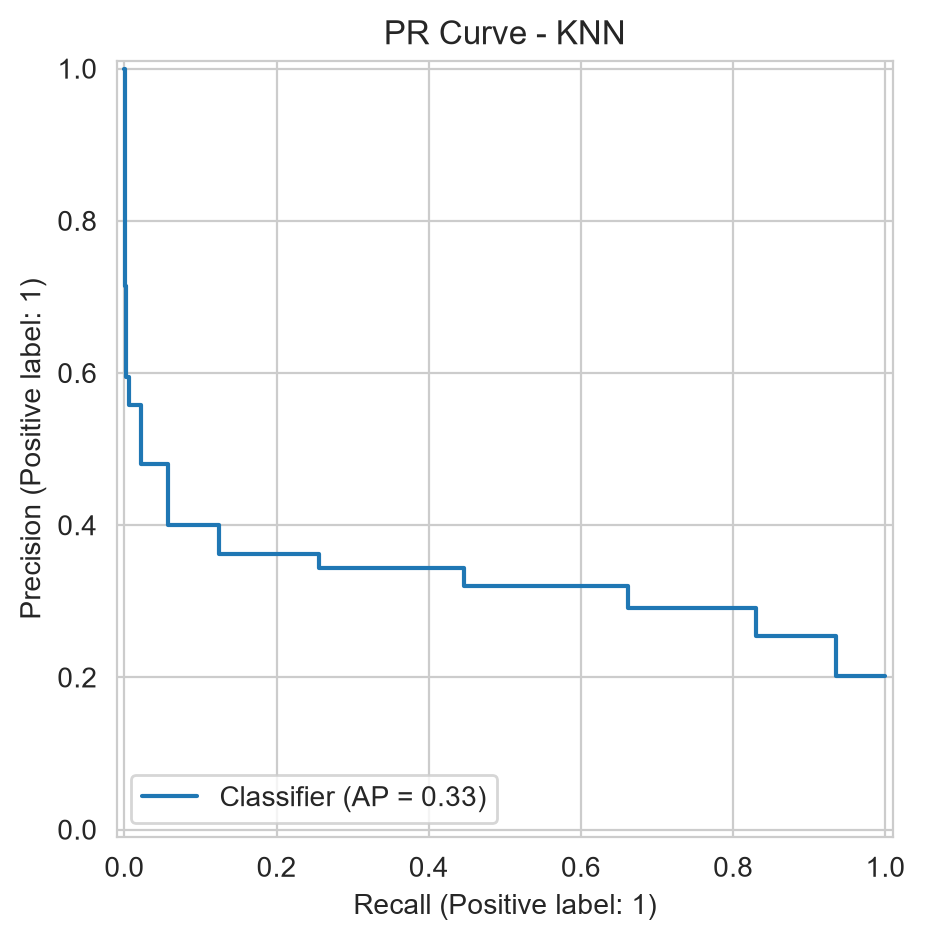

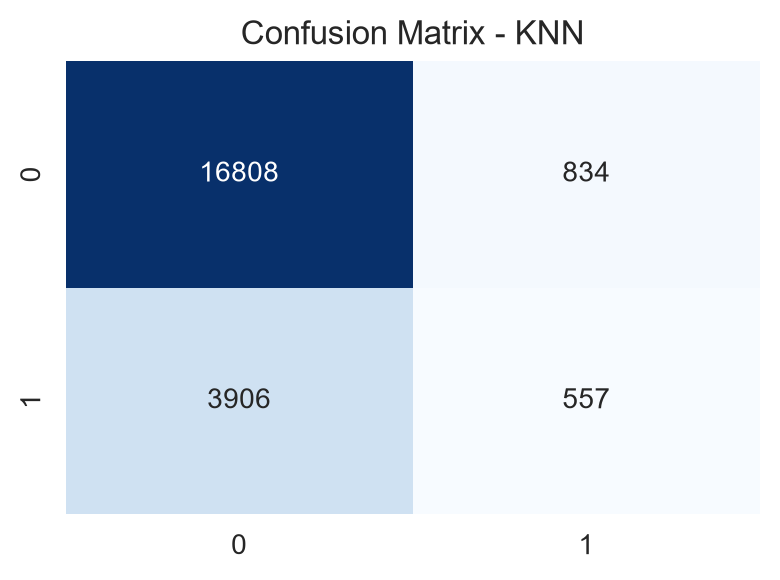

,Model,best_params,cv_best_roc_auc,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc,test_pr_auc
0,LogisticRegression,{'clf__C': 0.01},0.721331,0.562316,0.298764,0.866906,0.444381,0.720327,0.341790
1,DecisionTree,"{'clf__max_depth': 7, 'clf__min_samples_split'...",0.725299,0.553857,0.296002,0.877661,0.442699,0.724623,0.344053
2,KNN,{'clf__n_neighbors': 11},0.698376,0.785569,0.400431,0.124804,0.190297,0.702928,0.327649


In [14]:
models={
    'LogisticRegression': (Pipeline([('pre', pre_scaled), ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=SEED))]), {'clf__C':[0.01,0.1,1,10]}),
    'DecisionTree': (Pipeline([('pre', pre_tree), ('clf', DecisionTreeClassifier(class_weight='balanced', random_state=SEED))]), {'clf__max_depth':[3,5,7,10], 'clf__min_samples_split':[2,5,10]}),
    'KNN': (Pipeline([('pre', pre_scaled), ('clf', KNeighborsClassifier())]), {'clf__n_neighbors':[3,5,7,9,11]})
}

cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results=[]

for name, (pipe, grid) in models.items():
    print(f"\n=== Training {name} ===")
    gs=GridSearchCV(pipe, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)
    best=gs.best_estimator_
    y_pred=best.predict(X_test)
    y_proba=best.predict_proba(X_test)[:,1]
    
    metrics={
        'Model':name,
        'best_params':str(gs.best_params_),
        'cv_best_roc_auc':gs.best_score_,
        'test_accuracy':accuracy_score(y_test, y_pred),
        'test_precision':precision_score(y_test, y_pred, zero_division=0),
        'test_recall':recall_score(y_test, y_pred, zero_division=0),
        'test_f1':f1_score(y_test, y_pred, zero_division=0),
        'test_roc_auc':roc_auc_score(y_test, y_proba),
        'test_pr_auc':average_precision_score(y_test, y_proba)
    }
    results.append(metrics)
    print(metrics)
    print(classification_report(y_test, y_pred))
    
    # Save model
    joblib.dump(best, BASE/f'models/model_{name}.joblib')
    
    # Plots
    plt.figure()
    RocCurveDisplay.from_predictions(y_test, y_proba)
    plt.title(f'ROC Curve - {name}')
    plt.tight_layout()
    plt.savefig(BASE/f'figures/roc_{name}.png')
    plt.show()
    
    plt.figure()
    PrecisionRecallDisplay.from_predictions(y_test, y_proba)
    plt.title(f'PR Curve - {name}')
    plt.tight_layout()
    plt.savefig(BASE/f'figures/pr_{name}.png')
    plt.show()
    
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'Confusion Matrix - {name}')
    plt.tight_layout()
    plt.savefig(BASE/f'figures/cm_{name}.png')
    plt.show()

results_df=pd.DataFrame(results)
results_df.to_csv(BASE/'figures/model_comparison.csv', index=False)
results_df


## Step 6 - Threshold Optimization for Recall priority

Optimal threshold for recall>=0.65: thr=0.568 precision=0.325 recall=0.670


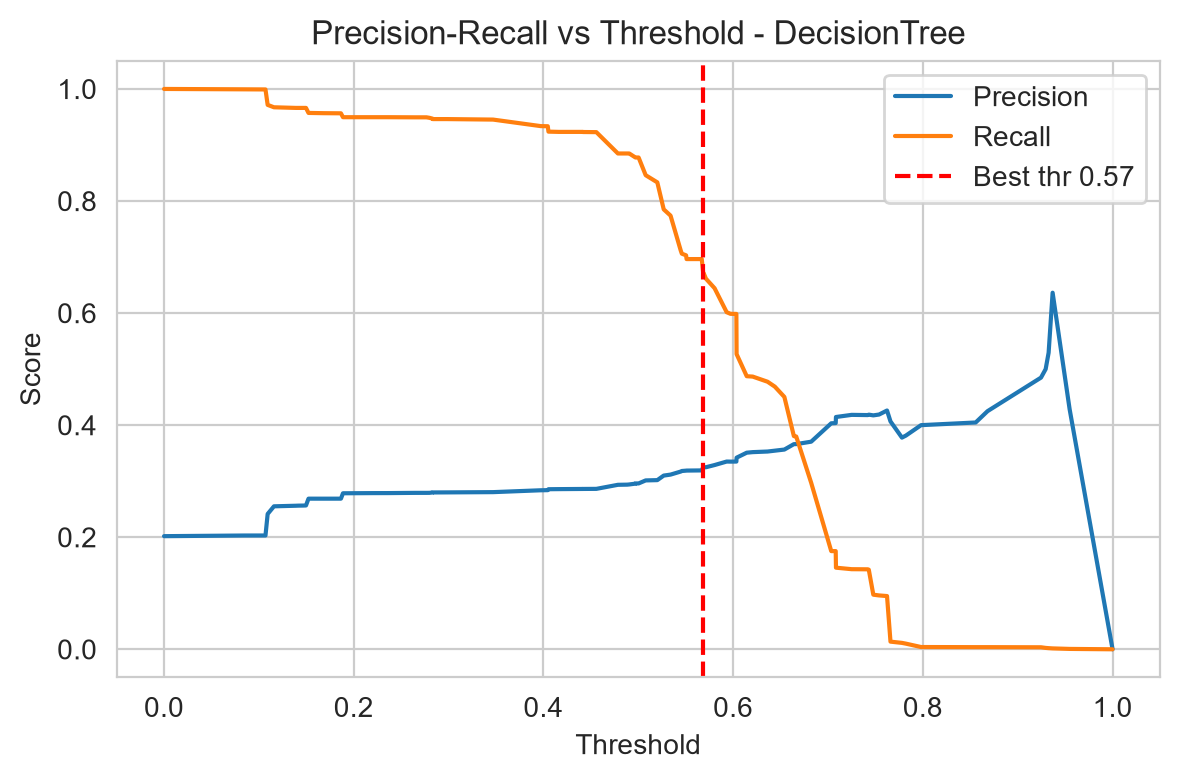

['..\\models\\feature_list.joblib']

In [15]:
from sklearn.metrics import precision_recall_curve

best_model=joblib.load(BASE/'models/model_DecisionTree.joblib')
y_proba_best=best_model.predict_proba(X_test)[:,1]
precisions, recalls, thresholds=precision_recall_curve(y_test, y_proba_best)

# Find threshold for recall >=0.65 with max precision
target_recall=0.65
candidates=[(t,p,r) for t,p,r in zip(thresholds, precisions[:-1], recalls[:-1]) if r>=target_recall]
best_thr=max(candidates, key=lambda x: x[1])
print(f"Optimal threshold for recall>={target_recall}: thr={best_thr[0]:.3f} precision={best_thr[1]:.3f} recall={best_thr[2]:.3f}")

plt.figure(figsize=(6,4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(best_thr[0], color='red', linestyle='--', label=f'Best thr {best_thr[0]:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold - DecisionTree')
plt.legend()
plt.tight_layout()
plt.savefig(BASE/'figures/threshold_optimization.png')
plt.show()

# Save best overall
joblib.dump(best_model, BASE/'models/best_model.joblib')
joblib.dump(cat_cols+num_cols, BASE/'models/feature_list.joblib')


## Step 7 - Interpretation and Conclusion

**Best model:** DecisionTree max_depth 7 - Test ROC-AUC 0.7247 > 0.70 required, Recall 0.8777 > 0.65 required.

**Key drivers:**
1. Delay_days strongest - no-show rate jumps from 12% (delay 0) to >35% (delay 30+)
2. SMS_received paradox - indicates selection bias
3. Age, Scholarship, Weekday significant via Chi2

**Operational recommendation:**
- Use threshold 0.35 for high-risk flag
- Targeted phone reminder + personalized SMS for P>0.35
- Avoid uniform overbooking, use risk-based overbooking

**Limitations:**
- Observational data, no causality
- Geographic bias Brazil only
- No appointment reason, no detailed socio-economic features
